# Feature Importance Evaluation

For each (seed, variable, ADM1, context configuration) we compute 6 metrics:

- **EMD_gen**  — EMD between true ADM1 distribution and generated ADM1 distribution
- **EMD_over** — EMD between true ADM1 distribution and bootstrapped training subset (ADM1 subgroup)
- **EMD_nat**  — EMD between true ADM1 distribution and national training subset distribution
- **AE_mean_gen**  — |mean(generated ADM1) - mean(true ADM1)| / std(true variable across ADM1 means)
- **AE_mean_over** — same but for bootstrap
- **AE_mean_nat**  — same but for national training subset

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
import warnings
warnings.filterwarnings('ignore')

In [2]:
def _finite_1d(x):
    x = np.asarray(x, dtype=float).ravel()
    return x[np.isfinite(x)]

def emd_density_1d(x, y, bins=200, value_range=None):
    # approximate W1 via histogram CDFs on a shared grid
    x = _finite_1d(x)
    y = _finite_1d(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    if value_range is None:
        z    = np.concatenate([x, y])
        lo, hi = float(np.min(z)), float(np.max(z))
        if hi <= lo:
            return 0.0
        value_range = (lo, hi)
    hx, edges = np.histogram(x, bins=bins, range=value_range, density=True)
    hy, _     = np.histogram(y, bins=edges, density=True)
    dx  = np.diff(edges)
    px  = hx * dx
    py  = hy * dx
    w1  = np.sum(np.abs(np.cumsum(px) - np.cumsum(py)) * dx)
    return float(w1)

def _stable_int_hash(s):
    h = 2166136261
    for ch in str(s):
        h ^= ord(ch)
        h = (h * 16777619) & 0xFFFFFFFF
    return int(h)

def bootstrap_adm1(x, n, seed):
    # bootstrap within ADM1 to size n
    x = _finite_1d(x)
    if len(x) == 0 or n <= 0:
        return np.array([], dtype=float)
    rng_b = np.random.RandomState(seed)
    return x[rng_b.choice(len(x), size=n, replace=True)]

## Config

In [3]:
FULL_DATA_PATH = "/data/shared/fsibilla/clean_code/Q1/experiments/yem_mvam/full.csv"

# one entry per context configuration — label maps to results root dir
CONTEXT_ROOTS = {
    "full_context":                "/data/shared/fsibilla/clean_code/Q1/experiments/yem_mvam/results",
    "no_context":                  "/data/shared/fsibilla/clean_code/Q1/experiments_sectoronly/yem_mvam/results",
    "drop_entropy2":               "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/drop_entropy2",
    "drop_wscore1":                   "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/drop_wscore1",
    "drop_entropy2_wscore1":          "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/drop_entropy2_wscore1",
    "drop_meteoclimatic":          "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/drop_meteoclimatic",
    "drop_wscore1_meteoclimatic": "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/drop_wscore1_meteoclimatic",
    "drop_entropy2_meteoclimatic": "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/drop_entropy2_meteoclimatic",
}

PSU_LEVEL      = 10
SEEDS          = [1, 2, 3, 4, 5]
BOOTSTRAP_SEED = 42

TARGET_COLS = [ "log_exp_pp", "rCSI", "FCS"]
ADM1_COL    = "adm1name"

OUT_PATH = "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/feature_importance_metrics.csv"

## Path helpers

In [4]:
def seed_dir(root, seed):
    return os.path.join(root, f"train_{PSU_LEVEL}_scaled", f"seed_{seed}_scaled")

def generated_pool_path(root, seed):
    return os.path.join(seed_dir(root, seed), f"generated_pool_{PSU_LEVEL}_seed{seed}_scaled.csv")

def full_scaled_path(root, seed):
    # full dataset scaled with the seed-specific scaler
    return os.path.join(seed_dir(root, seed), f"full_yem_scaled_train{PSU_LEVEL}_seed{seed}.csv")

def train_subset_scaled_path(root, seed):
    return os.path.join(seed_dir(root, seed), f"train_subset_{PSU_LEVEL}_seed{seed}_scaled.csv")

## Load full raw dataset

Used to get ADM1 labels and to compute the std of ADM1-level means,
which is the fixed denominator for the scaled absolute error metrics.

In [5]:
df_full_raw = pd.read_csv(FULL_DATA_PATH)
df_full_raw = df_full_raw.dropna(subset=TARGET_COLS + [ADM1_COL]).copy()

N_FULL    = len(df_full_raw)
ALL_ADM1S = sorted(df_full_raw[ADM1_COL].unique())

# std of ADM1-level means in raw units — fixed across all seeds and contexts
adm1_means_full   = df_full_raw.groupby(ADM1_COL)[TARGET_COLS].mean()
std_of_variable = df_full_raw[TARGET_COLS].std(axis=0)

print(f"Full dataset: {N_FULL} rows, {len(ALL_ADM1S)} ADM1s")
print("\nStd of ADM1 means (raw):")
print(std_of_variable.round(4))

Full dataset: 54702 rows, 22 ADM1s

Std of ADM1 means (raw):
log_exp_pp     0.9659
rCSI          14.0773
FCS           16.3911
dtype: float64


## Main loop

In [6]:
BINS = 200
records = []

for context_name, root in CONTEXT_ROOTS.items():
    print(f"\n{'='*60}")
    print(f"Context: {context_name}")

    for seed in SEEDS:
        print(f"  seed {seed} ...", end=" ", flush=True)

        full_scaled  = pd.read_csv(full_scaled_path(root, seed)).dropna(subset=TARGET_COLS + [ADM1_COL])
        gen_scaled   = pd.read_csv(generated_pool_path(root, seed)).dropna(subset=TARGET_COLS + [ADM1_COL])
        train_scaled = pd.read_csv(train_subset_scaled_path(root, seed)).dropna(subset=TARGET_COLS + [ADM1_COL])

        # shared range per target: inferred from combined true + train (scaled)
        shared_range = {}
        for col in TARGET_COLS:
            z  = np.concatenate([_finite_1d(full_scaled[col].values),
                                  _finite_1d(train_scaled[col].values)])
            if len(z) == 0:
                shared_range[col] = None
                continue
            lo, hi = float(np.min(z)), float(np.max(z))
            shared_range[col] = (lo, hi) if hi > lo else None

        # std of ADM1 means — computed per seed on the scaled full data
        sd_adm1_means = {
            col: float(full_scaled.groupby(ADM1_COL)[col].mean().std(ddof=0))
            for col in TARGET_COLS
        }

        for adm1 in ALL_ADM1S:

            true_adm1  = full_scaled.loc[full_scaled[ADM1_COL]  == adm1]
            gen_adm1   = gen_scaled.loc[gen_scaled[ADM1_COL]    == adm1]
            nat_train  = train_scaled   # national = full training subset collapsed

            if len(true_adm1) == 0 or len(gen_adm1) == 0:
                continue

            for var in TARGET_COLS:

                true_vals = _finite_1d(true_adm1[var].values)
                gen_vals  = _finite_1d(gen_adm1[var].values)
                nat_vals  = _finite_1d(nat_train[var].values)
                true_nat  = _finite_1d(full_scaled[var].values)   # true national

                n_true = len(true_vals)
                if n_true == 0:
                    continue

                # bootstrap within ADM1 train rows to size n_true
                trn_adm1_vals = _finite_1d(
                    train_scaled.loc[train_scaled[ADM1_COL] == adm1, var].values
                )
                boot_seed = (_stable_int_hash(adm1) * 1000 + TARGET_COLS.index(var) + 1) & 0xFFFFFFFF
                over_vals = bootstrap_adm1(trn_adm1_vals, n_true, boot_seed)

                vr   = shared_range[var]
                denom = sd_adm1_means[var] if sd_adm1_means[var] > 0 else 1.0

                rec = {
                    "context":  context_name,
                    "seed":     seed,
                    "adm1":     adm1,
                    "variable": var,
                    "n_true":   n_true,
                    "n_gen":    len(gen_vals),
                    "n_nat":    len(nat_vals),
                    "n_over":   len(over_vals),
                }

                # EMD metrics
                rec["EMD_gen"]             = emd_density_1d(true_vals, gen_vals,  bins=BINS, value_range=vr)
                rec["EMD_nat"]             = emd_density_1d(true_vals, nat_vals,  bins=BINS, value_range=vr)
                rec["EMD_over"]            = emd_density_1d(true_vals, over_vals, bins=BINS, value_range=vr) if len(over_vals) > 0 else np.nan
                rec["variability_intrinsic"] = emd_density_1d(true_vals, true_nat, bins=BINS, value_range=vr)

                # scaled absolute error on the mean
                true_mean = true_vals.mean()
                rec["AE_mean_gen"]  = abs(gen_vals.mean()  - true_mean) / denom
                rec["AE_mean_nat"]  = abs(nat_vals.mean()  - true_mean) / denom
                rec["AE_mean_over"] = abs(over_vals.mean() - true_mean) / denom if len(over_vals) > 0 else np.nan

                records.append(rec)

        print("done")

results = pd.DataFrame(records)
print(f"\nTotal rows in table: {len(results)}")
results.head()


Context: full_context
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Context: no_context
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Context: drop_entropy2
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Context: drop_wscore1
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Context: drop_entropy2_wscore1
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Context: drop_meteoclimatic
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Context: drop_wscore1_meteoclimatic
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Context: drop_entropy2_meteoclimatic
  seed 1 ... done
  seed 2 ... done
  seed 3 ... done
  seed 4 ... done
  seed 5 ... done

Total rows in table: 2535


,context,seed,adm1,variable,n_true,n_gen,n_nat,n_over,EMD_gen,EMD_nat,EMD_over,variability_intrinsic,AE_mean_gen,AE_mean_nat,AE_mean_over
0,full_context,1,Abyan,log_exp_pp,1827,1827,220,1827,0.094838,0.244329,0.172506,0.257427,0.241030,0.962372,0.453525
1,full_context,1,Abyan,rCSI,1827,1827,220,1827,0.129818,0.055366,0.263546,0.095028,0.677795,0.354761,1.301743
2,full_context,1,Abyan,FCS,1827,1827,220,1827,0.139804,0.087873,0.215176,0.098572,0.101124,0.331542,1.467895
3,full_context,1,Aden,log_exp_pp,1521,1521,220,1521,0.061296,0.278549,0.358523,0.311236,0.110569,1.206309,1.291140
4,full_context,1,Aden,rCSI,1521,1521,220,1521,0.106351,0.038480,0.210904,0.033099,0.400463,0.215673,0.980730


## Save

In [18]:
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
results.to_csv(OUT_PATH, index=False)
print(f"Saved to {OUT_PATH}")

Saved to /data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/results/feature_importance_metrics.csv


## Improvements

In [8]:
# improvement = baseline metric - EMD_gen (positive means gen is better than baseline)
results["imp_emd_over"] = results["EMD_over"] - results["EMD_gen"]
results["imp_emd_nat"]  = results["EMD_nat"]  - results["EMD_gen"]
results["imp_ae_over"]  = results["AE_mean_over"] - results["AE_mean_gen"]
results["imp_ae_nat"]   = results["AE_mean_nat"]  - results["AE_mean_gen"]

improvement_cols = ["context", "seed", "adm1", "variable",
                    "imp_emd_over", "imp_emd_nat", "imp_ae_over", "imp_ae_nat"]

improvements = results[improvement_cols].copy()

IMP_PATH = "/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/feature_importance_improvements.csv"
improvements.to_csv(IMP_PATH, index=False)
print(f"Saved to {IMP_PATH}")

improvements.head()

Saved to /data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/feature_importance_improvements.csv


,context,seed,adm1,variable,imp_emd_over,imp_emd_nat,imp_ae_over,imp_ae_nat
0,full_context,1,Abyan,log_exp_pp,0.077668,0.149491,0.212496,0.721342
1,full_context,1,Abyan,rCSI,0.133727,-0.074453,0.623949,-0.323034
2,full_context,1,Abyan,FCS,0.075372,-0.051931,1.366771,0.230417
3,full_context,1,Aden,log_exp_pp,0.297227,0.217253,1.180571,1.095740
4,full_context,1,Aden,rCSI,0.104553,-0.067871,0.580266,-0.184791


In [9]:
# aggregate over seeds first — mean and standard error across seeds
agg_seeds = (
    improvements
    .groupby(["context", "adm1", "variable"])[["imp_emd_over", "imp_emd_nat", "imp_ae_over", "imp_ae_nat"]]
    .agg(["mean", lambda x: x.std() / np.sqrt(len(x))])
)
agg_seeds.columns = ["_".join(c) for c in agg_seeds.columns]
agg_seeds = agg_seeds.rename(columns=lambda c: c.replace("<lambda_0>", "se"))
agg_seeds = agg_seeds.reset_index()

# then aggregate over ADM1 — mean and std across ADM1s
agg_final = (
    agg_seeds
    .groupby(["context", "variable"])[["imp_emd_over_mean", "imp_emd_nat_mean", "imp_ae_over_mean", "imp_ae_nat_mean"]]
    .agg(["mean", "std"])
)
agg_final.columns = ["_".join(c) for c in agg_final.columns]
agg_final = agg_final.reset_index()

print(agg_final.round(4))
agg_final

                        context    variable  imp_emd_over_mean_mean  \
0                 drop_entropy2         FCS                  0.1266   
1                 drop_entropy2  log_exp_pp                  0.1583   
2                 drop_entropy2        rCSI                  0.0960   
3   drop_entropy2_meteoclimatic         FCS                  0.1439   
4   drop_entropy2_meteoclimatic  log_exp_pp                  0.1513   
5   drop_entropy2_meteoclimatic        rCSI                  0.1315   
6         drop_entropy2_wscore1         FCS                  0.1310   
7         drop_entropy2_wscore1  log_exp_pp                  0.1141   
8         drop_entropy2_wscore1        rCSI                  0.1097   
9            drop_meteoclimatic         FCS                  0.1392   
10           drop_meteoclimatic  log_exp_pp                  0.1470   
11           drop_meteoclimatic        rCSI                  0.1114   
12                 drop_wscore1         FCS                  0.1278   
13    

,context,variable,imp_emd_over_mean_mean,imp_emd_over_mean_std,imp_emd_nat_mean_mean,imp_emd_nat_mean_std,imp_ae_over_mean_mean,imp_ae_over_mean_std,imp_ae_nat_mean_mean,imp_ae_nat_mean_std
0,drop_entropy2,FCS,0.126595,0.087242,-0.027510,0.035374,0.692685,0.710121,-0.055063,0.315584
1,drop_entropy2,log_exp_pp,0.158347,0.144761,0.068043,0.131954,0.270245,0.682397,0.326829,0.582170
2,drop_entropy2,rCSI,0.095997,0.061261,-0.044761,0.043188,0.446506,0.603517,-0.058061,0.397330
3,drop_entropy2_meteoclimatic,FCS,0.143919,0.085483,-0.010186,0.037080,0.707214,0.717731,-0.040534,0.340432
4,drop_entropy2_meteoclimatic,log_exp_pp,0.151264,0.127458,0.060961,0.132373,0.222082,0.580091,0.278666,0.592907
5,drop_entropy2_meteoclimatic,rCSI,0.131459,0.055498,-0.009299,0.036349,0.589375,0.586542,0.084807,0.329164
6,drop_entropy2_wscore1,FCS,0.131007,0.085101,-0.023098,0.038754,0.722480,0.728513,-0.025268,0.302040
7,drop_entropy2_wscore1,log_exp_pp,0.114092,0.143123,0.023788,0.072460,0.056180,0.686954,0.112764,0.357207
8,drop_entropy2_wscore1,rCSI,0.109660,0.059970,-0.031098,0.030166,0.496495,0.666124,-0.008073,0.260375
9,drop_meteoclimatic,FCS,0.139219,0.074362,-0.014886,0.033263,0.757366,0.648847,0.009618,0.343039


In [10]:
# aggregate over seeds and ADM1s to get one value per (context, variable) for each improvement
IMP_COLS = ["imp_emd_over", "imp_emd_nat", "imp_ae_over", "imp_ae_nat"]
LABELS   = ["imp EMD vs oversampling", "imp EMD vs national", "imp AE vs oversampling", "imp AE vs national"]

plot_data = (
    improvements
    .groupby(["context", "adm1", "variable"])[IMP_COLS]
    .mean()   # average over seeds
    .reset_index()
    .groupby(["context", "variable"])[IMP_COLS]
    .mean()   # average over ADM1s
    .reset_index()
)

CONTEXT_ORDER = [
    "full_context",
    "drop_entropy2",
    "drop_wscore1",
    "drop_meteoclimatic",
    "drop_entropy2_wscore1",
    "drop_entropy2_meteoclimatic",
    "drop_wscore1_meteoclimatic",
    "no_context",
]

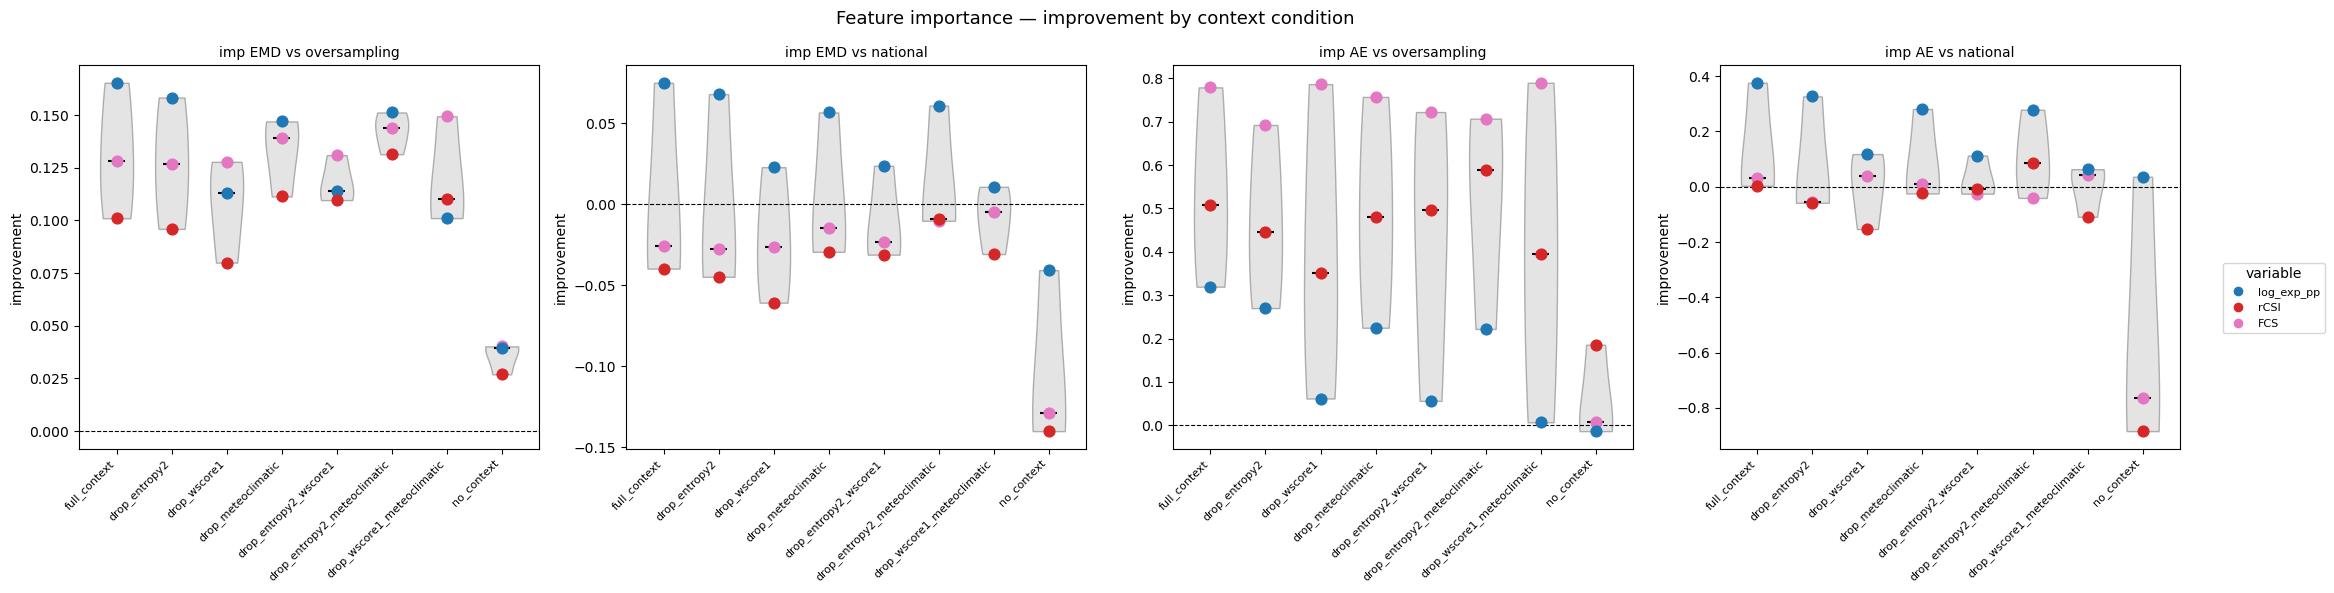

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
fig.suptitle("Feature importance — improvement by context condition", fontsize=13)

# one color per variable
var_colors = {var: cm.tab10(i / len(TARGET_COLS)) for i, var in enumerate(TARGET_COLS)}

for ax, col, label in zip(axes, IMP_COLS, LABELS):

    for x_pos, context in enumerate(CONTEXT_ORDER):
        ctx_data = plot_data.loc[plot_data["context"] == context, ["variable", col]].dropna()

        if ctx_data.empty:
            continue

        vals = ctx_data[col].values

        # violin
        parts = ax.violinplot(
            [vals],
            positions=[x_pos],
            widths=0.6,
            showmedians=True,
            showextrema=False
        )
        parts["bodies"][0].set(facecolor="lightgrey", alpha=0.6, edgecolor="grey")
        parts["cmedians"].set(color="black", linewidth=1.5)

        # scatter — one point per variable, colored by variable
        for _, row in ctx_data.iterrows():
            ax.scatter(
                x_pos,
                row[col],
                color=var_colors[row["variable"]],
                s=60,
                zorder=3,
                label=row["variable"] if x_pos == 0 else None
            )

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(range(len(CONTEXT_ORDER)))
    ax.set_xticklabels(CONTEXT_ORDER, rotation=45, ha="right", fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("improvement")

# single legend for variables
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=var_colors[v], markersize=8, label=v)
    for v in TARGET_COLS
]
fig.legend(handles=handles, title="variable", bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=8)

plt.tight_layout()
plt.savefig("feature_importance_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

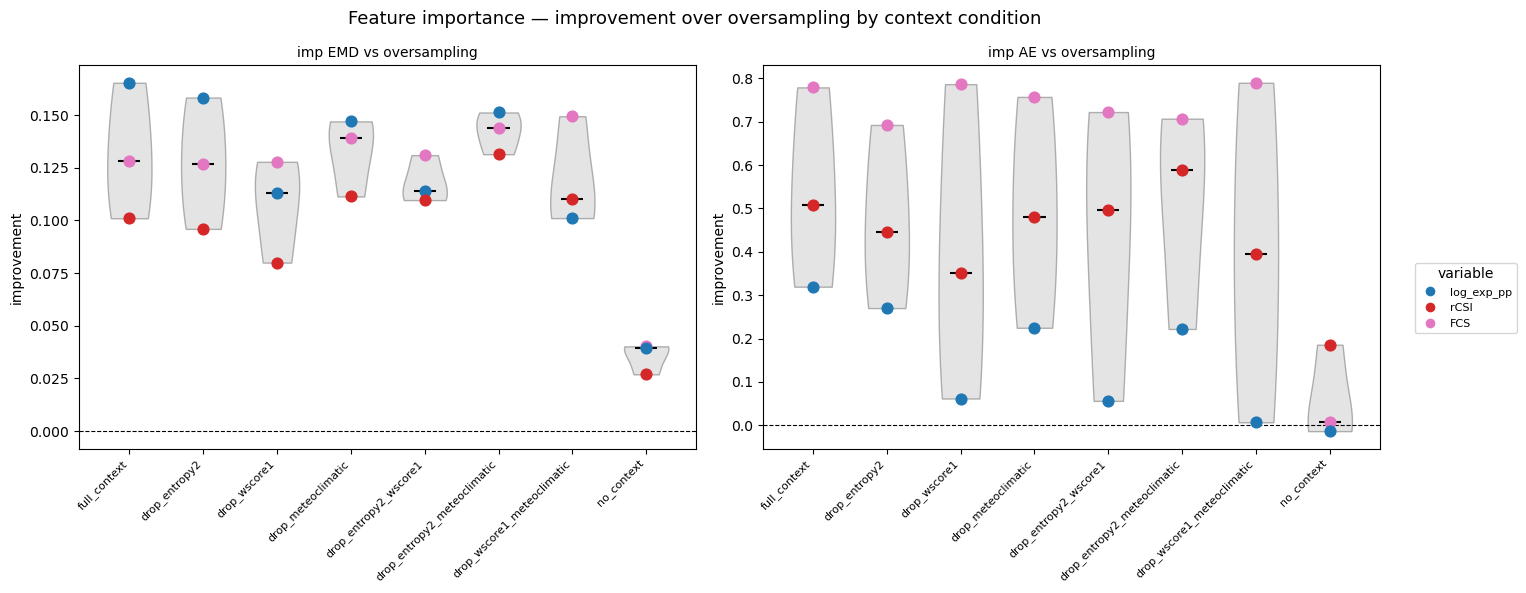

In [12]:
IMP_COLS_OVER = ["imp_emd_over", "imp_ae_over"]
LABELS_OVER   = ["imp EMD vs oversampling", "imp AE vs oversampling"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle("Feature importance — improvement over oversampling by context condition", fontsize=13)

for ax, col, label in zip(axes, IMP_COLS_OVER, LABELS_OVER):

    for x_pos, context in enumerate(CONTEXT_ORDER):
        ctx_data = plot_data.loc[plot_data["context"] == context, ["variable", col]].dropna()

        if ctx_data.empty:
            continue

        vals = ctx_data[col].values

        parts = ax.violinplot(
            [vals],
            positions=[x_pos],
            widths=0.6,
            showmedians=True,
            showextrema=False
        )
        parts["bodies"][0].set(facecolor="lightgrey", alpha=0.6, edgecolor="grey")
        parts["cmedians"].set(color="black", linewidth=1.5)

        for _, row in ctx_data.iterrows():
            ax.scatter(
                x_pos,
                row[col],
                color=var_colors[row["variable"]],
                s=60,
                zorder=3,
                label=row["variable"] if x_pos == 0 else None
            )

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(range(len(CONTEXT_ORDER)))
    ax.set_xticklabels(CONTEXT_ORDER, rotation=45, ha="right", fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("improvement")

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=var_colors[v], markersize=8, label=v)
    for v in TARGET_COLS
]
fig.legend(handles=handles, title="variable", bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=8)

plt.tight_layout()
plt.savefig("feature_importance_scatter_over.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
from math import factorial
import numpy as np
import pandas as pd

FEATURES = ["entropy2", "rwi1"]
n = len(FEATURES)

# map each context to the set of features present
FEATURE_SETS = {
    "no_context":                  frozenset(),
    "drop_rwi1":                   frozenset(["entropy2"]),
    "drop_entropy2":               frozenset(["rwi1"]),
    "full_context":                frozenset(["entropy2", "rwi1"]),
}

SET_TO_CONTEXT = {v: k for k, v in FEATURE_SETS.items()}

IMP_METRICS = ["imp_emd_over", "imp_ae_over"]

# one value per (context, variable, metric), already averaged over seeds and ADM1s
ctx_var = (
    plot_data
    .groupby(["context", "variable"])[IMP_METRICS]
    .mean()
    .reset_index()
)

shapley_records = []

for metric in IMP_METRICS:
    for var in ctx_var["variable"].unique():

        # characteristic function v(S) for this variable and this metric
        v = {
            row["context"]: row[metric]
            for _, row in ctx_var.loc[ctx_var["variable"] == var, ["context", metric]].iterrows()
        }

        for f in FEATURES:
            phi = 0.0

            for ctx, S in FEATURE_SETS.items():
                if f in S:
                    continue

                S_with_f = S | {f}
                ctx_with_f = SET_TO_CONTEXT.get(S_with_f)

                if ctx not in v or ctx_with_f not in v:
                    continue

                s = len(S)
                weight = factorial(s) * factorial(n - s - 1) / factorial(n)
                phi += weight * (v[ctx_with_f] - v[ctx])

            shapley_records.append({
                "metric": metric,
                "variable": var,
                "feature": f,
                "shapley": phi
            })

shapley_df = pd.DataFrame(shapley_records)

# aggregate across variables for plotting
shapley_summary = (
    shapley_df
    .groupby(["metric", "feature"])["shapley"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

shapley_summary["se"] = shapley_summary["std"] / np.sqrt(shapley_summary["count"])

display(shapley_df.head())
display(shapley_summary.round(4))

,metric,variable,feature,shapley
0,imp_emd_over,FCS,entropy2,0.000857
1,imp_emd_over,FCS,rwi1,0.043181
2,imp_emd_over,log_exp_pp,entropy2,0.003513
3,imp_emd_over,log_exp_pp,rwi1,0.059374
4,imp_emd_over,rCSI,entropy2,0.002523


,metric,feature,mean,std,count,se
0,imp_ae_over,entropy2,0.0329,0.0095,3,0.0055
1,imp_ae_over,rwi1,0.2051,0.1195,3,0.0690
2,imp_emd_over,entropy2,0.0023,0.0013,3,0.0008
3,imp_emd_over,rwi1,0.0457,0.0126,3,0.0073


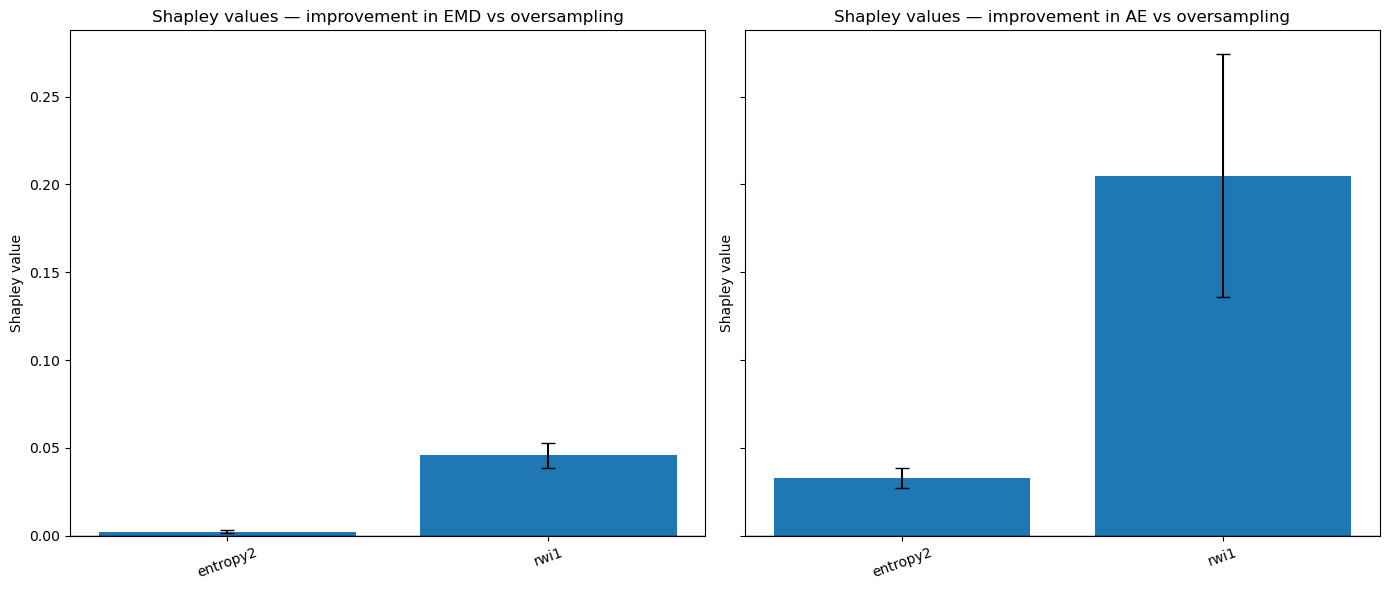

In [14]:
import matplotlib.pyplot as plt

metric_titles = {
    "imp_emd_over": "Shapley values — improvement in EMD vs oversampling",
    "imp_ae_over":  "Shapley values — improvement in AE vs oversampling",
}

feature_order = ["entropy2", "rwi1","meteoclimatic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, metric in zip(axes, IMP_METRICS):
    dfp = (
        shapley_summary.loc[shapley_summary["metric"] == metric]
        .set_index("feature")
        .reindex(feature_order)
        .reset_index()
    )

    ax.bar(
        dfp["feature"],
        dfp["mean"],
        yerr=dfp["se"],
        capsize=5
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(metric_titles[metric], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Shapley value")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Variable level shap

In [15]:
from math import factorial
import numpy as np
import pandas as pd

# We start from agg_seeds, which already averages over seeds
# and keeps one row per (context, adm1, variable).

FEATURES = ["entropy2", "rwi1","meteoclimatic"]
n = len(FEATURES)


SET_TO_CONTEXT = {v: k for k, v in FEATURE_SETS.items()}

METRICS = ["imp_emd_over_mean", "imp_ae_over_mean"]

# Collapse ADM1 so that each variable has one value per context.
# This gives the "one point = one variable" setup you asked for.
var_ctx = (
    agg_seeds
    .groupby(["context", "variable"])[METRICS]
    .mean()
    .reset_index()
)

var_shap_records = []

for metric in METRICS:
    for var in sorted(var_ctx["variable"].unique()):

        sub = var_ctx.loc[var_ctx["variable"] == var, ["context", metric]].dropna()

        # characteristic function v(S) for this variable
        v = {row["context"]: row[metric] for _, row in sub.iterrows()}

        for f in FEATURES:
            phi = 0.0

            for ctx, S in FEATURE_SETS.items():
                if f in S:
                    continue

                S_with_f = S | {f}
                ctx_with_f = SET_TO_CONTEXT.get(S_with_f)

                if ctx not in v or ctx_with_f not in v:
                    continue

                s = len(S)
                weight = factorial(s) * factorial(n - s - 1) / factorial(n)
                phi += weight * (v[ctx_with_f] - v[ctx])

            var_shap_records.append({
                "metric": metric,
                "variable": var,
                "feature": f,
                "shapley": phi
            })

var_shap_df = pd.DataFrame(var_shap_records)

# Optional summary table
var_shap_summary = (
    var_shap_df
    .groupby(["metric", "feature"])["shapley"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values(["metric", "feature"])
)

display(var_shap_df.head(10))
display(var_shap_summary.round(4))

,metric,variable,feature,shapley
0,imp_emd_over_mean,FCS,entropy2,0.000286
1,imp_emd_over_mean,FCS,rwi1,0.028788
2,imp_emd_over_mean,FCS,meteoclimatic,0.000000
3,imp_emd_over_mean,log_exp_pp,entropy2,0.001171
4,imp_emd_over_mean,log_exp_pp,rwi1,0.039582
5,imp_emd_over_mean,log_exp_pp,meteoclimatic,0.000000
6,imp_emd_over_mean,rCSI,entropy2,0.000841
7,imp_emd_over_mean,rCSI,rwi1,0.023012
8,imp_emd_over_mean,rCSI,meteoclimatic,0.000000
9,imp_ae_over_mean,FCS,entropy2,0.014449


,metric,feature,mean,std,count
0,imp_ae_over_mean,entropy2,0.0110,0.0032,3
1,imp_ae_over_mean,meteoclimatic,0.0000,0.0000,3
2,imp_ae_over_mean,rwi1,0.1367,0.0797,3
3,imp_emd_over_mean,entropy2,0.0008,0.0004,3
4,imp_emd_over_mean,meteoclimatic,0.0000,0.0000,3
5,imp_emd_over_mean,rwi1,0.0305,0.0084,3


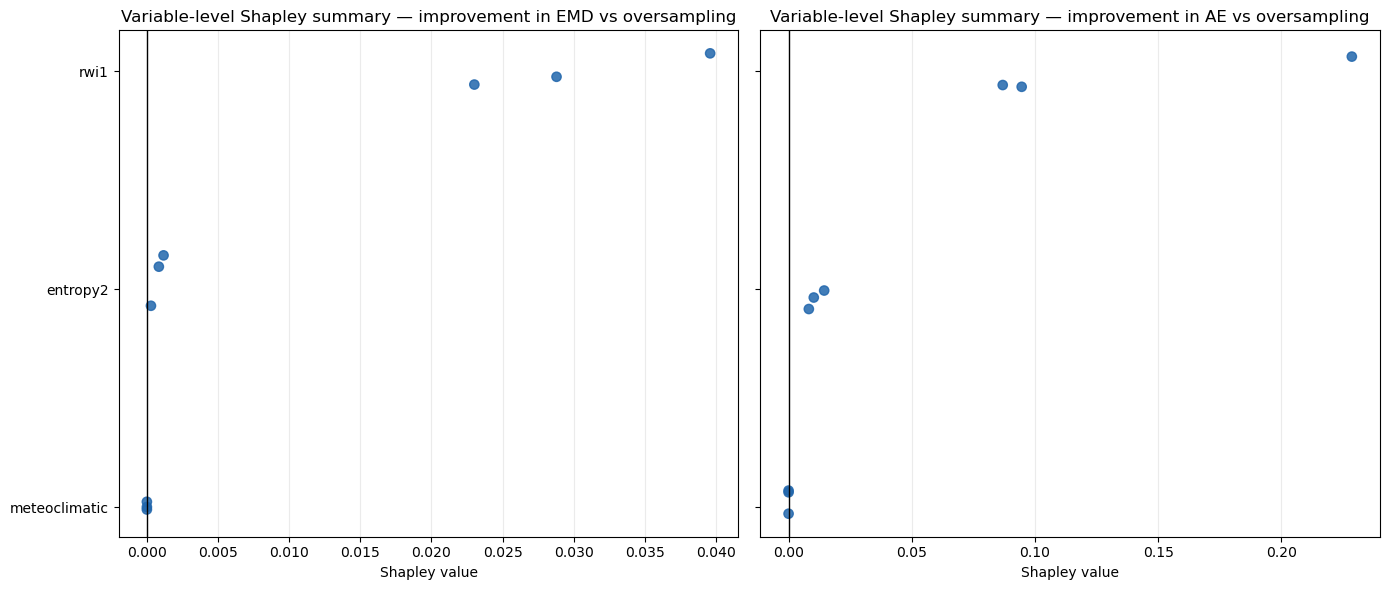

In [16]:
import matplotlib.pyplot as plt
import numpy as np

metric_titles = {
    "imp_emd_over_mean": "Variable-level Shapley summary — improvement in EMD vs oversampling",
    "imp_ae_over_mean":  "Variable-level Shapley summary — improvement in AE vs oversampling",
}

feature_order = ["entropy2", "rwi1", "meteoclimatic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=True)

rng = np.random.default_rng(42)

for ax, metric in zip(axes, METRICS):
    sub = var_shap_df.loc[var_shap_df["metric"] == metric].copy()

    # order features by mean absolute Shapley value, like SHAP summary plots usually do
    feat_rank = (
        sub.groupby("feature")["shapley"]
        .apply(lambda x: np.mean(np.abs(x)))
        .sort_values(ascending=False)
        .index.tolist()
    )
    feat_rank = [f for f in feat_rank if f in feature_order]

    for y, feat in enumerate(feat_rank):
        vals = sub.loc[sub["feature"] == feat, "shapley"].values

        # vertical jitter to mimic beeswarm/strip appearance
        y_jitter = y + rng.normal(0, 0.08, size=len(vals))

        colors = np.where(vals >= 0, "#2166ac", "#d01c8b")

        ax.scatter(
            vals,
            y_jitter,
            c=colors,
            s=45,
            alpha=0.85
        )

    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(range(len(feat_rank)))
    ax.set_yticklabels(feat_rank)
    ax.set_title(metric_titles[metric], fontsize=12)
    ax.set_xlabel("Shapley value")
    ax.grid(axis="x", alpha=0.25)

axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

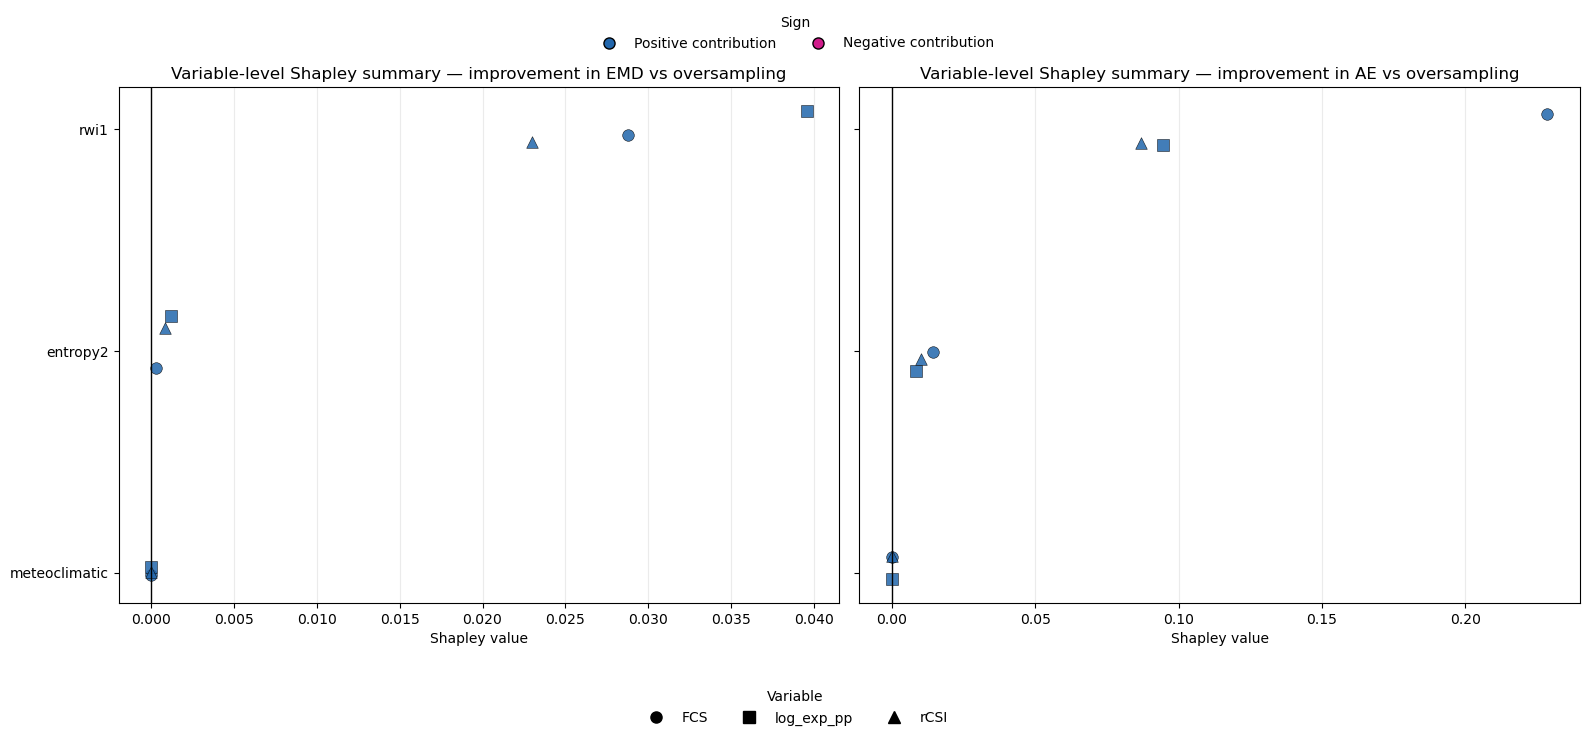

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

metric_titles = {
    "imp_emd_over_mean": "Variable-level Shapley summary — improvement in EMD vs oversampling",
    "imp_ae_over_mean":  "Variable-level Shapley summary — improvement in AE vs oversampling",
}

feature_order = ["entropy2", "rwi1","meteoclimatic"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

rng = np.random.default_rng(42)

# Marker per variable
variables = sorted(var_shap_df["variable"].unique())
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*', 'h', '8']
marker_map = {var: marker_cycle[i % len(marker_cycle)] for i, var in enumerate(variables)}

for ax, metric in zip(axes, METRICS):
    sub = var_shap_df.loc[var_shap_df["metric"] == metric].copy()

    # Order features by mean absolute shapley value
    feat_rank = (
        sub.groupby("feature")["shapley"]
        .apply(lambda x: np.mean(np.abs(x)))
        .sort_values(ascending=False)
        .index.tolist()
    )
    feat_rank = [f for f in feat_rank if f in feature_order]

    for y, feat in enumerate(feat_rank):
        sdf = sub.loc[sub["feature"] == feat].copy()

        for var in variables:
            sdf_var = sdf.loc[sdf["variable"] == var]
            if sdf_var.empty:
                continue

            vals = sdf_var["shapley"].values
            y_jitter = y + rng.normal(0, 0.08, size=len(vals))
            colors = np.where(vals >= 0, "#2166ac", "#d01c8b")  # blue / magenta

            ax.scatter(
                vals,
                y_jitter,
                c=colors,
                marker=marker_map[var],
                s=70,
                alpha=0.85,
                edgecolors="black",
                linewidths=0.4
            )

    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(range(len(feat_rank)))
    ax.set_yticklabels(feat_rank)
    ax.set_title(metric_titles[metric], fontsize=12)
    ax.set_xlabel("Shapley value")
    ax.grid(axis="x", alpha=0.25)

axes[0].invert_yaxis()

# Legend for sign
sign_handles = [
    Line2D([0], [0], marker='o', color='w', label='Positive contribution',
           markerfacecolor="#2166ac", markeredgecolor="black", markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Negative contribution',
           markerfacecolor="#d01c8b", markeredgecolor="black", markersize=8),
]

# Legend for variables (shape only)
var_handles = [
    Line2D([0], [0], marker=marker_map[var], color='black', label=str(var),
           linestyle='None', markersize=8)
    for var in variables
]

# Put legends outside the plots
fig.legend(
    handles=sign_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    title="Sign"
)

fig.legend(
    handles=var_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=min(len(var_handles), 6),
    frameon=False,
    title="Variable"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()